# Testing New Ephemeris and SPICE loading

In [57]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
import pandas as pd
import numpy as np
import spiceypy as spice
import matplotlib.pyplot as plt

In [59]:
from contigo.solar_system_ephem import SPICEEphem
from contigo.solar_system_ephem import SolarSystemEnvironment
from contigo.forces.third_body_acc import ThirdBodyAcc
from contigo.forces.tba_utils import tba_pairwise_numba
from contigo.utils import time_utils

### Test new Solar System Environement Class

SolarSystemEnvironment loads and caches ephemeris data with a time tolerance to save
on loading the same ephemeris data over and over.

In [60]:
sw_e = pd.read_hdf("./data/ESA_pod.hdf")

In [61]:
# check times 
et_t = time_utils.spice_time(pd.to_datetime((sw_e['DateTime'].to_numpy())),
                                             tscale='GPS',out_scale='ET')
gps_t = time_utils.spice_time(pd.to_datetime((sw_e['DateTime'].to_numpy())),
                                             tscale='GPS',out_scale='GPS') 

print('UTC should be 18 seconds behind GPS')
print('GPS time: ', sw_e['DateTime'][0])
print('UTC from et: ', spice.et2datetime(et_t)[0])

UTC should be 18 seconds behind GPS
GPS time:  2018-01-02 00:00:00
UTC from et:  2018-01-01 23:59:42+00:00


### Test SolarSystemEnvironment

- Load a small amount of data
- Call getting data from full array (should increase cache size)

In [62]:
ephem = SPICEEphem()
env = SolarSystemEnvironment(['SUN','MOON'], sp_et=et_t[0:500], sp_gps=gps_t[0:500],
                              tolerance=0.001,provider=ephem)

INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\de440s.bsp
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\naif0012.tls
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\earth_latest_high_prec.bpc


In [63]:
# Get the first 500 values of ephem
r_et, r_gps, r_pos = env.get_ephem(et_t[0:500],sp_gps=gps_t[0:500])
print(r_et.shape)
print(r_pos.shape)

(500,)
(2, 500, 3)


In [64]:
# Get the ephem for the full array
# This should increase the size of the cache
r_et, r_gps, r_pos = env.get_ephem(et_t,gps_t)
print(r_et.shape)
print(r_pos.shape)

(138240,)
(2, 138240, 3)


### Check errors in position from qauntization

Because we are using GPS time with no decimal seconds a tollerance of 1.0 or 0 should
give exact results back

In [65]:
bd_full = np.array([spice.spkpos(bd,et_t,'ITRF93','NONE','EARTH')[0]
            for bd in env.bodies])

(138240,)
(2, 138240, 3)
True


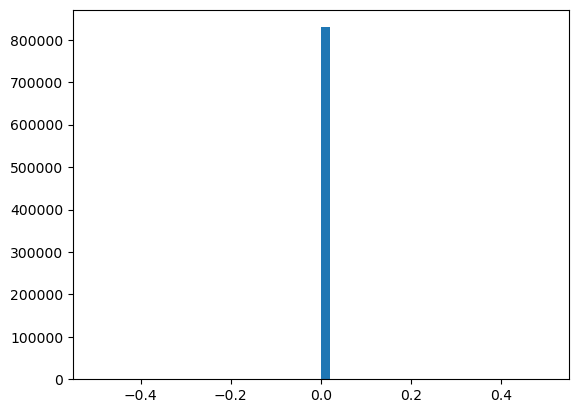

In [66]:
r_et, r_gps, r_pos = env.get_ephem(et_t, gps_t)
print(r_et.shape)
print(r_pos.shape)
print(np.array_equal(r_pos, bd_full))

perc_err = 100*(r_pos.flatten()-bd_full.flatten())/bd_full.flatten()
id_max = np.unravel_index(perc_err.argmax(), r_pos.shape)

_ = plt.hist(perc_err,bins=50)

### Test Thirdbody Calculations and Look at error

In [68]:
spos = sw_e[['x','y','z']].to_numpy()
stime = sw_e['DateTime']
x = sw_e['x'].to_numpy()
y = sw_e['y'].to_numpy()
z = sw_e['z'].to_numpy()
tba_cont = ThirdBodyAcc(spos=spos,stime=pd.to_datetime(stime.to_numpy()),body=['SUN','MOON'],scale='GPS')  
tba_cont.calc_tba()

tba_acc = tba_cont.get_tba()
print(tba_acc.shape)

INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\de440s.bsp
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\naif0012.tls
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\earth_latest_high_prec.bpc


(2, 138240, 3)


In [69]:
ephem_provider = SPICEEphem()
env = SolarSystemEnvironment(['SUN','MOON'], sp_et=et_t, sp_gps=gps_t, tolerance=0,provider=ephem_provider)
r_et, r_gps, r_pos = env.get_ephem(et_t, gps_t)
bd_acc = tba_pairwise_numba(spos, r_pos, tba_cont.GM)
print(bd_acc.shape)

INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\de440s.bsp
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\naif0012.tls
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\earth_latest_high_prec.bpc


(2, 138240, 3)


-9.005938675805368e-11
-9.005938675805368e-11
True
0.0


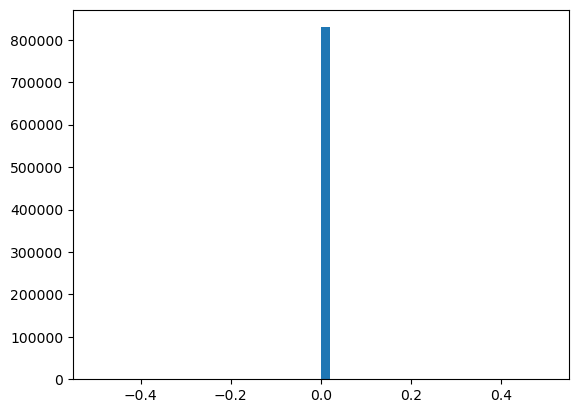

In [70]:
print(tba_acc[0,0,0])
print(bd_acc[0,0,0])
print(np.array_equal(tba_acc,bd_acc))

perc_err = 100*(bd_acc.flatten()-tba_acc.flatten())/tba_acc.flatten()
print(np.abs(perc_err).max())
_ = plt.hist(perc_err,bins=50)

### Test Third Body Accelleration Force Model with Constellation

In [71]:
from contigo.constellation import Constellation
from contigo.forces.third_body_acc import ThirdBodyEnv

In [73]:
hdf_sc = Constellation(state_file=r'D:\GitHub\contigo_edr\data\ESA_pod.hdf', 
                    time_col='DateTime', x_col='x', y_col='y', z_col='z',
                    vx_col='vx', vy_col='vy', vz_col='vz', 
                    sc_id_col='filename', sc_fn_slc=slice(-11,-8),
                    tscale_input='GPS', 
                    sc_mass=4.3e+02, cr=1.8, srp_area=1)

acc = ThirdBodyEnv().acceleration(hdf_sc,env)

In [74]:
print(np.array_equal(acc['ESA'],tba_acc))
print(np.array_equal(acc['ESA'],bd_acc))

True
True
